# Interview Questions and Practice Problems

This notebook covers the most common statistics and probability questions asked in data science, ML engineering, and quantitative analyst interviews. Each section provides the question, a concise conceptual answer, and (where applicable) working code.

---

## Section 1: Probability Fundamentals

In [1]:
# Q1: If you flip a fair coin 3 times, what is the probability of getting exactly 2 heads?
from scipy.stats import binom
p = binom.pmf(k=2, n=3, p=0.5)
print(f'P(X=2 | n=3, p=0.5) = {p:.4f}')
print('Answer: C(3,2) * 0.5^2 * 0.5^1 = 3 * 0.25 * 0.5 = 0.375')


P(X=2 | n=3, p=0.5) = 0.3750
Answer: C(3,2) * 0.5^2 * 0.5^1 = 3 * 0.25 * 0.5 = 0.375


In [2]:
# Q2: In a room of 23 people, what is the probability that at least two share a birthday?
# (Birthday Paradox)
import numpy as np
def birthday_prob(n):
    p_no_match = np.prod([(365 - i) / 365 for i in range(n)])
    return 1 - p_no_match

for n in [10, 23, 30, 50, 70]:
    print(f'n={n:>2}: P(at least one shared birthday) = {birthday_prob(n):.4f}')
print()
print('At n=23 the probability exceeds 50% — most people find this surprising.')
print('Root cause: we are counting PAIRS of people, not individuals.')
print('There are C(23,2) = 253 pairs, each with 1/365 chance of matching.')


n=10: P(at least one shared birthday) = 0.1169
n=23: P(at least one shared birthday) = 0.5073
n=30: P(at least one shared birthday) = 0.7063
n=50: P(at least one shared birthday) = 0.9704
n=70: P(at least one shared birthday) = 0.9992

At n=23 the probability exceeds 50% — most people find this surprising.
Root cause: we are counting PAIRS of people, not individuals.
There are C(23,2) = 253 pairs, each with 1/365 chance of matching.


In [3]:
# Q3: A box has 3 red and 2 blue balls. You draw 2 without replacement.
# What is P(both red)?
from math import comb
p = comb(3, 2) / comb(5, 2)
print(f'P(both red) = C(3,2)/C(5,2) = {comb(3,2)}/{comb(5,2)} = {p:.4f}')
print('Equivalent: P(R1) * P(R2|R1) = (3/5) * (2/4) = 0.30')


P(both red) = C(3,2)/C(5,2) = 3/10 = 0.3000
Equivalent: P(R1) * P(R2|R1) = (3/5) * (2/4) = 0.30


## Section 2: Distributions

In [4]:
from scipy import stats
import numpy as np

# Q4: What is the expected number of rolls of a fair die to get a 6?
# Geometric distribution: E[X] = 1/p
p = 1/6
print(f'Expected rolls to get a 6: E[X] = 1/p = 1/{p:.4f} = {1/p:.1f}')
print()

# Q5: Calls arrive at a rate of 10/hour. What is P(more than 15 calls in 1 hour)?
# Poisson distribution
lam = 10
p_more_15 = 1 - stats.poisson.cdf(15, mu=lam)
print(f'P(X > 15 | lambda=10) = {p_more_15:.4f}')
print()

# Q6: What are the mean and variance of a Binomial(n=100, p=0.3)?
n, p = 100, 0.3
print(f'Binomial(n={n}, p={p}): mean={n*p}, variance={n*p*(1-p)}')


Expected rolls to get a 6: E[X] = 1/p = 1/0.1667 = 6.0

P(X > 15 | lambda=10) = 0.0487

Binomial(n=100, p=0.3): mean=30.0, variance=21.0


In [5]:
# Q7: What is the 95th percentile of a Standard Normal distribution?
z_95 = stats.norm.ppf(0.95)
print(f'95th percentile of N(0,1): z = {z_95:.4f}')
print()

# Q8: If X ~ N(mu=50, sigma=10), what is P(40 < X < 60)?
mu, sigma = 50, 10
p = stats.norm.cdf(60, mu, sigma) - stats.norm.cdf(40, mu, sigma)
print(f'P(40 < X < 60) = {p:.4f}  (this is the 68% rule: mu +/- 1 sigma)')
print()

# Q9: What is the difference between PDF and CDF?
print('PDF (Probability Density Function): f(x) = density at point x.')
print('  For continuous X: P(a<=X<=b) = integral of f(x) from a to b.')
print('  f(x) >= 0 but can exceed 1.')
print()
print('CDF (Cumulative Distribution Function): F(x) = P(X <= x).')
print('  Always between 0 and 1, non-decreasing.')
print('  PDF = derivative of CDF.')


95th percentile of N(0,1): z = 1.6449

P(40 < X < 60) = 0.6827  (this is the 68% rule: mu +/- 1 sigma)

PDF (Probability Density Function): f(x) = density at point x.
  For continuous X: P(a<=X<=b) = integral of f(x) from a to b.
  f(x) >= 0 but can exceed 1.

CDF (Cumulative Distribution Function): F(x) = P(X <= x).
  Always between 0 and 1, non-decreasing.
  PDF = derivative of CDF.


## Section 3: Hypothesis Testing

In [6]:
from scipy import stats
import numpy as np

# Q10: What is the difference between Type I and Type II errors?
print('Type I Error (alpha): Reject H0 when H0 is TRUE  (false positive)')
print('Type II Error (beta): Fail to reject H0 when H0 is FALSE  (false negative)')
print()
print('Power = 1 - beta = probability of correctly detecting a true effect.')
print()

# Q11: What does a p-value of 0.03 mean?
print('Q11: p=0.03 means:')
print('  If H0 were true, there would be only a 3% chance of observing data')
print('  as extreme as we did (or more extreme).')
print()
print('It does NOT mean:')
print('  - P(H0 is true) = 3%')
print('  - The effect is large or practically important')
print('  - The result will replicate')


Type I Error (alpha): Reject H0 when H0 is TRUE  (false positive)
Type II Error (beta): Fail to reject H0 when H0 is FALSE  (false negative)

Power = 1 - beta = probability of correctly detecting a true effect.

Q11: p=0.03 means:
  If H0 were true, there would be only a 3% chance of observing data
  as extreme as we did (or more extreme).

It does NOT mean:
  - P(H0 is true) = 3%
  - The effect is large or practically important
  - The result will replicate


In [7]:
# Q12: When do you use a t-test vs z-test?
print('z-test: population sigma is KNOWN (rare in practice)')
print('t-test: population sigma is UNKNOWN (estimated from sample)')
print()
print('For large n (>30), t and z give nearly identical results (t -> z).')
print('Prefer t-test in practice — it is strictly more correct.')
print()

# Q13: What is the difference between one-tailed and two-tailed tests?
print('Two-tailed: H1: mu != mu_0  (reject in EITHER direction)')
print('  Split alpha equally: alpha/2 in each tail')
print()
print('One-tailed: H1: mu > mu_0 or H1: mu < mu_0  (reject in ONE direction)')
print('  All alpha in one tail — more power but only valid if direction is pre-specified')
print()
print('Rule: Always pre-register direction before seeing data. Post-hoc one-tailing is p-hacking.')


z-test: population sigma is KNOWN (rare in practice)
t-test: population sigma is UNKNOWN (estimated from sample)

For large n (>30), t and z give nearly identical results (t -> z).
Prefer t-test in practice — it is strictly more correct.

Two-tailed: H1: mu != mu_0  (reject in EITHER direction)
  Split alpha equally: alpha/2 in each tail

One-tailed: H1: mu > mu_0 or H1: mu < mu_0  (reject in ONE direction)
  All alpha in one tail — more power but only valid if direction is pre-specified

Rule: Always pre-register direction before seeing data. Post-hoc one-tailing is p-hacking.


In [8]:
# Q14: What is the difference between statistical and practical significance?
import numpy as np
from scipy import stats

rng = np.random.default_rng(42)

# Huge sample: tiny effect becomes statistically significant
n = 100_000
a = rng.normal(50.00, 10, n)
b = rng.normal(50.01, 10, n)   # 0.01 unit difference — practically meaningless
t, p = stats.ttest_ind(a, b, equal_var=False)

pooled_std = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
d = (b.mean() - a.mean()) / pooled_std

print(f'Mean A={a.mean():.4f}, Mean B={b.mean():.4f}, difference={b.mean()-a.mean():.4f}')
print(f'p-value: {p:.4g}  (statistically significant!)')
print(f"Cohen's d: {d:.4f}  (negligible effect — d < 0.2)")
print()
print('With n=100,000, even a 0.01-unit difference is "significant".')
print('Always report effect size alongside p-values.')


Mean A=49.9577, Mean B=50.0372, difference=0.0795
p-value: 0.07626  (statistically significant!)
Cohen's d: 0.0079  (negligible effect — d < 0.2)

With n=100,000, even a 0.01-unit difference is "significant".
Always report effect size alongside p-values.


## Section 4: Bayesian Statistics

In [9]:
import numpy as np
from scipy import stats

# Q15: What is the difference between frequentist and Bayesian CIs?
print('Frequentist 95% CI: If we repeated the experiment 100 times,')
print('  ~95 of the intervals would contain the true parameter.')
print('  The parameter is fixed; the interval is random.')
print()
print('Bayesian 95% Credible Interval: Given the data, there is a 95% posterior')
print('  probability that the parameter lies in this interval.')
print('  The parameter is treated as a random variable.')
print()

# Q16: What prior would you use for a coin-flip proportion?
print('Q16: Conjugate prior for proportion p in binomial model:')
print('  Prior: Beta(alpha, beta)  -->  Posterior: Beta(alpha+k, beta+n-k)')
print()
print('  Beta(1,1) = Uniform prior (completely non-informative)')
print('  Beta(2,2) = Weakly informative (slight belief that p ~ 0.5)')
print('  Beta(10,10) = Strong belief that p is near 0.5')


Frequentist 95% CI: If we repeated the experiment 100 times,
  ~95 of the intervals would contain the true parameter.
  The parameter is fixed; the interval is random.

Bayesian 95% Credible Interval: Given the data, there is a 95% posterior
  probability that the parameter lies in this interval.
  The parameter is treated as a random variable.

Q16: Conjugate prior for proportion p in binomial model:
  Prior: Beta(alpha, beta)  -->  Posterior: Beta(alpha+k, beta+n-k)

  Beta(1,1) = Uniform prior (completely non-informative)
  Beta(2,2) = Weakly informative (slight belief that p ~ 0.5)
  Beta(10,10) = Strong belief that p is near 0.5


## Section 5: Regression and ML Statistics

In [10]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np

rng = np.random.default_rng(42)
X = rng.normal(0, 1, (100, 1))
y = 2 * X.ravel() + 1 + rng.normal(0, 0.5, 100)

# Q17: What are the OLS assumptions?
print('OLS Assumptions (Gauss-Markov):')
print('  1. Linearity: E[y|X] = X*beta')
print('  2. No perfect multicollinearity: X has full column rank')
print('  3. Exogeneity: E[epsilon|X] = 0  (no omitted variable bias)')
print('  4. Homoscedasticity: Var[epsilon|X] = sigma^2 (constant)')
print('  5. No autocorrelation: Cov[epsilon_i, epsilon_j] = 0')
print('  6. (For inference) Normality of residuals: epsilon ~ N(0, sigma^2)')
print()

# Fit with statsmodels for inference
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()
print('OLS Coefficients with inference:')
print(model.summary().tables[1])


OLS Assumptions (Gauss-Markov):
  1. Linearity: E[y|X] = X*beta
  2. No perfect multicollinearity: X has full column rank
  3. Exogeneity: E[epsilon|X] = 0  (no omitted variable bias)
  4. Homoscedasticity: Var[epsilon|X] = sigma^2 (constant)
  5. No autocorrelation: Cov[epsilon_i, epsilon_j] = 0
  6. (For inference) Normality of residuals: epsilon ~ N(0, sigma^2)

OLS Coefficients with inference:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9977      0.049     20.316      0.000       0.900       1.095
x1             2.0596      0.063     32.479      0.000       1.934       2.185


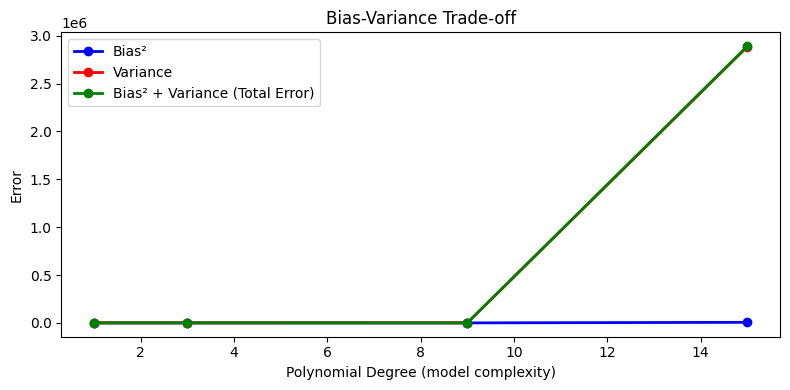

Low complexity (degree 1): high bias, low variance -> underfitting
High complexity (degree 15): low bias, high variance -> overfitting


In [11]:
# Q18: What is the bias-variance trade-off?
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(42)
n_train = 30
n_test  = 500
true_fn = lambda x: np.sin(2 * np.pi * x)

x_test  = np.linspace(0, 1, n_test)

degrees  = [1, 3, 9, 15]
n_reps   = 200
bias_sq  = []
variance  = []

for deg in degrees:
    preds = []
    for _ in range(n_reps):
        x_tr = rng.uniform(0, 1, n_train)
        y_tr = true_fn(x_tr) + rng.normal(0, 0.3, n_train)
        model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
        model.fit(x_tr.reshape(-1,1), y_tr)
        preds.append(model.predict(x_test.reshape(-1,1)))
    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    bias_sq.append(np.mean((mean_pred - true_fn(x_test))**2))
    variance.append(np.mean(preds.var(axis=0)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(degrees, bias_sq,  'b-o', lw=2, label='Bias²')
ax.plot(degrees, variance, 'r-o', lw=2, label='Variance')
ax.plot(degrees, [b+v for b,v in zip(bias_sq, variance)],
        'g-o', lw=2, label='Bias² + Variance (Total Error)')
ax.set_xlabel('Polynomial Degree (model complexity)')
ax.set_ylabel('Error')
ax.set_title('Bias-Variance Trade-off')
ax.legend()
plt.tight_layout()
plt.show()
print('Low complexity (degree 1): high bias, low variance -> underfitting')
print('High complexity (degree 15): low bias, high variance -> overfitting')


## Section 6: Experimental Design

In [12]:
from statsmodels.stats.power import TTestIndPower, NormalIndPower
import numpy as np

# Q19: How do you determine sample size for an experiment?
print('Sample size determination requires 4 inputs:')
print('  1. alpha (significance level, typically 0.05)')
print('  2. power (1 - beta, typically 0.80)')
print('  3. effect size (Cohen\'s d for means, Cohen\'s h for proportions)')
print('  4. test type (one-tailed or two-tailed)')
print()

analysis = TTestIndPower()
print('Required n per group (two-sample t-test, alpha=0.05, power=0.80):')
for d in [0.2, 0.5, 0.8]:
    n = analysis.solve_power(effect_size=d, alpha=0.05, power=0.80)
    print(f'  d={d}: n={int(np.ceil(n))} per group')
print()

# Q20: What happens to power when you increase sample size?
print('Power increases with:')
print('  + Larger n (more information)')
print('  + Larger true effect size (easier to detect)')
print('  + Larger alpha (less strict threshold, but more false positives)')
print('  + One-tailed vs two-tailed (more power but requires pre-specified direction)')


Sample size determination requires 4 inputs:
  1. alpha (significance level, typically 0.05)
  2. power (1 - beta, typically 0.80)
  3. effect size (Cohen's d for means, Cohen's h for proportions)
  4. test type (one-tailed or two-tailed)

Required n per group (two-sample t-test, alpha=0.05, power=0.80):
  d=0.2: n=394 per group
  d=0.5: n=64 per group
  d=0.8: n=26 per group

Power increases with:
  + Larger n (more information)
  + Larger true effect size (easier to detect)
  + Larger alpha (less strict threshold, but more false positives)
  + One-tailed vs two-tailed (more power but requires pre-specified direction)


In [13]:
# Q21: What is the difference between correlation and covariance?
import numpy as np
rng = np.random.default_rng(42)
X = rng.multivariate_normal([0, 0], [[4, 3], [3, 9]], 200)
x, y = X[:,0], X[:,1]

cov = np.cov(x, y)[0,1]
cor = np.corrcoef(x, y)[0,1]

print(f'Covariance(x,y) = {cov:.4f}  (units: units_x * units_y — hard to interpret)')
print(f'Correlation(x,y)= {cor:.4f}  (dimensionless, always in [-1, 1])')
print()
print('Pearson r = Cov(X,Y) / (sigma_X * sigma_Y)')
print(f'Verification: {cov / (x.std(ddof=1) * y.std(ddof=1)):.4f} (should match r)')


Covariance(x,y) = 3.2527  (units: units_x * units_y — hard to interpret)
Correlation(x,y)= 0.5692  (dimensionless, always in [-1, 1])

Pearson r = Cov(X,Y) / (sigma_X * sigma_Y)
Verification: 0.5692 (should match r)


## Section 7: Quick-Fire Conceptual Questions

**Q22. What is the Central Limit Theorem?**  
The distribution of the sample mean $\bar{X}$ converges to $\mathcal{N}(\mu, \sigma^2/n)$ as $n \to \infty$, regardless of the population distribution — provided the population has finite variance.

**Q23. What is the difference between standard deviation and standard error?**  
SD measures spread of individual observations. SE = $\sigma/\sqrt{n}$ measures uncertainty about the sample mean — it shrinks as $n$ grows.

**Q24. What is a confounding variable?**  
A variable that causally affects both the treatment/exposure and the outcome, creating a spurious correlation between them. Example: age confounds the education–income relationship.

**Q25. What is Simpson's Paradox?**  
A trend that appears in combined data disappears or reverses in every subgroup. Caused by a lurking confounder that creates unequal group sizes.

**Q26. Why does Bonferroni become too conservative with many tests?**  
Bonferroni controls the Family-Wise Error Rate — P(any false positive). With thousands of tests (genomics, feature selection), it requires each test to reach $\alpha/m$, which is so small that genuine effects are also missed. Benjamini-Hochberg controls the False Discovery Rate instead — the expected *proportion* of false positives among rejections.

**Q27. Explain the difference between L1 and L2 regularisation.**  
L2 (Ridge): adds $\lambda\|w\|^2_2$ — penalises large weights quadratically, shrinks all weights toward zero, keeps all features. Equivalent to a Gaussian prior.  
L1 (Lasso): adds $\lambda\|w\|_1$ — penalises sum of absolute values, drives some weights exactly to zero (sparse solution). Equivalent to a Laplace prior. Performs feature selection implicitly.

**Q28. What is cross-entropy loss and why do we use it for classification?**  
Cross-entropy $= -\sum_c y_c \log(\hat{p}_c)$ where $y_c$ is the true label and $\hat{p}_c$ is the predicted probability. Minimising it is equivalent to MLE under a categorical distribution. Unlike MSE, it gives large gradients when the model is confidently wrong — enabling fast learning.

**Q29. What is the difference between MLE and MAP estimation?**  
MLE: maximise $P(\text{data}|\theta)$ — uses only the data.  
MAP: maximise $P(\theta|\text{data}) \propto P(\text{data}|\theta) \cdot P(\theta)$ — incorporates a prior. MAP with Gaussian prior = Ridge regression. As $n \to \infty$, MAP → MLE (data overwhelms the prior).

**Q30. What is the bootstrap and when would you use it?**  
Resampling with replacement from the observed data to estimate the sampling distribution of any statistic. Use it when: (1) no closed-form formula exists for the CI (median, ratio, correlation), (2) the normality assumption fails, or (3) the sample is small. Core principle of Random Forests (bagging).

## Section 8: Coding Challenges

In [14]:
import numpy as np
from scipy import stats

# Challenge 1: Implement a two-sample t-test from scratch
def welch_ttest(a, b):
    """Two-sample Welch t-test. Returns (t_stat, p_value, df)."""
    n_a, n_b   = len(a), len(b)
    mean_a, mean_b = np.mean(a), np.mean(b)
    var_a,  var_b  = np.var(a, ddof=1), np.var(b, ddof=1)

    se   = np.sqrt(var_a/n_a + var_b/n_b)
    t    = (mean_a - mean_b) / se

    # Welch-Satterthwaite degrees of freedom
    df = (var_a/n_a + var_b/n_b)**2 / (
         (var_a/n_a)**2/(n_a-1) + (var_b/n_b)**2/(n_b-1)
    )
    p  = 2 * stats.t.sf(abs(t), df=df)
    return t, p, df

rng = np.random.default_rng(42)
a = rng.normal(0, 1, 30)
b = rng.normal(0.5, 1.5, 25)

t_manual, p_manual, df = welch_ttest(a, b)
t_scipy,  p_scipy  = stats.ttest_ind(a, b, equal_var=False)

print('From scratch vs scipy:')
print(f'  t : {t_manual:.6f}  vs  {t_scipy:.6f}')
print(f'  p : {p_manual:.6f}  vs  {p_scipy:.6f}')
print('  Match:', np.isclose(t_manual, t_scipy) and np.isclose(p_manual, p_scipy))


From scratch vs scipy:
  t : -2.372608  vs  -2.372608
  p : 0.022498  vs  0.022498
  Match: True


In [15]:
import numpy as np

# Challenge 2: Implement Cohen's d from scratch
def cohens_d(a, b):
    pooled_std = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std

rng = np.random.default_rng(42)
control   = rng.normal(100, 15, 50)
treatment = rng.normal(110, 15, 50)
d = cohens_d(treatment, control)
print(f"Cohen's d = {d:.4f}")
print(f"Effect: {'large' if abs(d)>=0.8 else 'medium' if abs(d)>=0.5 else 'small'}")
print()

# Challenge 3: Implement bootstrap CI from scratch
def bootstrap_ci(data, statistic=np.mean, B=5000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    boot_stats = [statistic(rng.choice(data, size=len(data), replace=True)) for _ in range(B)]
    lo = np.percentile(boot_stats, 100 * alpha/2)
    hi = np.percentile(boot_stats, 100 * (1 - alpha/2))
    return lo, hi

data = rng.exponential(scale=20, size=40)
lo, hi = bootstrap_ci(data, statistic=np.median)
print(f'Bootstrap 95% CI for median: ({lo:.2f}, {hi:.2f})')
print(f'Sample median: {np.median(data):.2f}')


Cohen's d = 0.5000
Effect: small

Bootstrap 95% CI for median: (7.80, 21.86)
Sample median: 15.35
